In [4]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



In [31]:
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
class_map = word_and_speaker_encodings['word_idx_to_word']


# use new model map 
model_class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
model_word_id_to_word = {v: k for k, v in model_class_map.items()}

## Get model results on Harmonic speech 

In [12]:
# # Use version_0 for Harmonic speech generated with shift f0 function
# # Use version_1 for Harmonic speech generated with STRAIGHT resynth via - StraightDummySynth.m

# parent_path = Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_harmonic_speech_attn_task_0dB_SNR_all_targets_MultiDistractorAttnCNN/version_1/')
# harmonic_file = parent_path.rglob("*.csv")
# harmonic_results = pd.read_csv(next(harmonic_file))

# # For clean, use version_1 for Harmonic speech generated with shift f0 function
# # For clean, use version_2 for Harmonic speech generated with STRAIGHT resynth via - StraightDummySynth.m

# clean_path = Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_harmonic_speech_attn_task_clean_all_targets_MultiDistractorAttnCNN/version_2/')
# clean_harmonic_file = clean_path.rglob("*.csv")
# clean_harmonic_results = pd.read_csv(next(clean_harmonic_file))


### Get results from jitter_fn rendered harmonic speech 

In [64]:
parent_path = Path('/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/')

harmonic_path = parent_path / 'TIMIT_harmonic_speech_jitter_render_attn_task_0dB_SNR_all_targets_word_task_mono_arch_v04'

harmonic_file = harmonic_path.rglob("*.csv")
harmonic_results = pd.read_csv(next(harmonic_file))

clean_harmonic_path = parent_path / 'TIMIT_harmonic_speech_jitter_render_attn_task_clean_all_targets_word_task_mono_arch_v04'

clean_harmonic_path = clean_harmonic_path.rglob('*.csv')
clean_harmonic_results = pd.read_csv(next(clean_harmonic_path))


In [65]:
harmonic_results = harmonic_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in harmonic_results.index})
harmonic_results['pred_word_ix'] = harmonic_results['pred_word_ix'].astype('int') 

In [66]:
clean_harmonic_results = clean_harmonic_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in clean_harmonic_results.index})
clean_harmonic_results['pred_word_ix'] = clean_harmonic_results['pred_word_ix'].astype('int') 

### Get metadata for harmonic stimuli

In [67]:
### import parent model stim df
out_path = Path('/om2/user/imgriff/datasets/timit/harmonic_timit/')

harmonic_meta_data = pd.read_pickle(out_path / 'all_targets_harmonic_single_distractor_0dB_SNR_jitter_fn_render.pdpkl')

In [68]:
harmonic_meta_data.head(2)

,signal,speaker,speaker_sex,sentence_type,word_int,mixture_signal,cue_signal,cue_speaker,cue_word,distractor_signal,...,snrs,word,_original_timit_index,source,sr,signal_length,sentence_id,dialect_region,data_split,distractor_word_ints
0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",fdaw0,f,sx,552,"[-0.00024411545, -0.00024411545, -0.0002441154...","[-1.3554327e-05, -1.3554327e-05, -1.3554327e-0...",fdaw0,ashamed,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",...,0,programs,15,train-dr1-fdaw0-sx146,20000,40000,146,dr1,train,night
1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",fdaw0,f,sx,461,"[4.7168479e-07, 4.7168479e-07, 4.7168479e-07, ...","[9.511216e-05, 9.511216e-05, 9.511216e-05, 9.5...",fdaw0,answer,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",...,0,novel,17,train-dr1-fdaw0-sx326,20000,40000,326,dr1,train,present


In [69]:
harmonic_results['guessed_word'] = harmonic_results['pred_word_ix'].map(model_word_id_to_word)

### Get metadata from timit df 
harmonic_results['true_word'] = harmonic_meta_data.loc[harmonic_results.orig_df_ix, ['word']].values
harmonic_results['distractor_words'] = harmonic_meta_data.loc[harmonic_results.orig_df_ix, ['distractor_words']].values
harmonic_results['distractor_sex'] = harmonic_meta_data.loc[harmonic_results.orig_df_ix, ['distractor_sex']].values
harmonic_results['snr'] = harmonic_meta_data.loc[harmonic_results.orig_df_ix, ['snrs']].values.astype('str')
harmonic_results['distractor_condition'] = harmonic_meta_data.loc[harmonic_results.orig_df_ix, ['distractor_conditions']].values.astype('str')
harmonic_results['target_sex'] = harmonic_meta_data.loc[harmonic_results.orig_df_ix, ['speaker_sex']].values



In [70]:
harmonic_results['distractor_condition'] = 'Harmonic'

In [71]:
clean_harmonic_results['guessed_word'] = clean_harmonic_results['pred_word_ix'].map(model_word_id_to_word)

### Get metadata from timit df 
clean_harmonic_results['true_word'] = harmonic_meta_data.loc[clean_harmonic_results.orig_df_ix, ['word']].values
# clean_harmonic_results['distractor_words'] = harmonic_meta_data.loc[clean_harmonic_results.orig_df_ix, ['distractor_words']].values
# clean_harmonic_results['distractor_sex'] = harmonic_meta_data.loc[clean_harmonic_results.orig_df_ix, ['distractor_sex']].values
# clean_harmonic_results['snr'] = harmonic_meta_data.loc[clean_harmonic_results.orig_df_ix, ['snrs']].values.astype('str')
# clean_harmonic_results['distractor_condition'] = harmonic_meta_data.loc[clean_harmonic_results.orig_df_ix, ['distractor_conditions']].values.astype('str')
clean_harmonic_results['target_sex'] = harmonic_meta_data.loc[clean_harmonic_results.orig_df_ix, ['speaker_sex']].values



In [72]:
clean_harmonic_results['distractor_condition'] = 'Harmonic Clean'

## Get Whispered results

In [73]:
parent_path = Path('/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/')

whisper_path = parent_path / 'TIMIT_whispered_speech_attn_task_0dB_SNR_all_targets_word_task_mono_arch_v04'

whispered_file = whisper_path.rglob("*.csv")
whispered_results = pd.read_csv(next(whispered_file))

clean_whisper_path = parent_path / 'TIMIT_whispered_speech_attn_task_clean_all_targets_word_task_mono_arch_v04'

clean_whisper_path = clean_whisper_path.rglob('*.csv')
clean_whispered_results = pd.read_csv(next(clean_whisper_path))



In [74]:
clean_whispered_results = clean_whispered_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, )
                     #  index={ix:f"trial {ix}" for ix in harmonic_results.index})
clean_whispered_results['pred_word_ix'] = clean_whispered_results['pred_word_ix'].astype('int') 

In [75]:
whispered_results = whispered_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, )
                     #  index={ix:f"trial {ix}" for ix in harmonic_results.index})
whispered_results['pred_word_ix'] = whispered_results['pred_word_ix'].astype('int') 

### Get whispered meta data

In [76]:
### import parent model stim df
out_path = Path('/om2/user/imgriff/datasets/timit/whispered_timit/')

whisper_meta_data = pd.read_pickle(out_path / 'all_targets_whispered_single_distractor_0dB_SNR.pdpkl')

In [77]:
clean_whispered_results['guessed_word'] = clean_whispered_results['pred_word_ix'].map(model_word_id_to_word)

### Get metadata from timit df 
clean_whispered_results['true_word'] = whisper_meta_data.loc[clean_whispered_results.orig_df_ix, ['word']].values
# clean_whispered_results['distractor_words'] = whisper_meta_data.loc[clean_whispered_results.orig_df_ix, ['distractor_words']].values
# clean_whispered_results['distractor_sex'] = whisper_meta_data.loc[clean_whispered_results.orig_df_ix, ['distractor_sex']].values
# clean_whispered_results['snr'] = whisper_meta_data.loc[clean_whispered_results.orig_df_ix, ['snrs']].values.astype('str')
# clean_whispered_results['distractor_condition'] = whisper_meta_data.loc[clean_whispered_results.orig_df_ix, ['distractor_conditions']].values.astype('str')
clean_whispered_results['target_sex'] = whisper_meta_data.loc[clean_whispered_results.orig_df_ix, ['speaker_sex']].values



In [78]:
clean_whispered_results['distractor_condition'] = "Whispered Clean"

In [79]:
whispered_results['guessed_word'] = whispered_results['pred_word_ix'].map(model_word_id_to_word)

### Get metadata from timit df 
whispered_results['true_word'] = whisper_meta_data.loc[whispered_results.orig_df_ix, ['word']].values
whispered_results['distractor_words'] = whisper_meta_data.loc[whispered_results.orig_df_ix, ['distractor_words']].values
whispered_results['distractor_sex'] = whisper_meta_data.loc[whispered_results.orig_df_ix, ['distractor_sex']].values
whispered_results['snr'] = whisper_meta_data.loc[whispered_results.orig_df_ix, ['snrs']].values.astype('str')
whispered_results['distractor_condition'] = whisper_meta_data.loc[whispered_results.orig_df_ix, ['distractor_conditions']].values.astype('str')
whispered_results['target_sex'] = whisper_meta_data.loc[whispered_results.orig_df_ix, ['speaker_sex']].values



In [80]:
whispered_results.head()

,true_word_ix,accuracy,pred_word_ix,model_confidence,orig_df_ix,guessed_word,true_word,distractor_words,distractor_sex,snr,distractor_condition,target_sex
0,539.0,0.0,280,0.103673,0,garden,programs,night,m,0,Whispered,f
1,460.0,0.0,82,0.126751,1,brought,novel,present,m,0,Whispered,f
2,617.0,0.0,24,0.057820,2,along,should,always,m,0,Whispered,f
3,632.0,0.0,459,0.093996,3,nothing,social,would,f,0,Whispered,f
4,375.0,0.0,21,0.439257,4,allowed,light,common,m,0,Whispered,f


## Get Inharmonic Results

In [81]:
parent_path = Path('/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_timit_task/')

whisper_path = parent_path / 'TIMIT_inharmonic_speech_attn_task_0dB_SNR_all_targets_word_task_mono_arch_v04'

inharmonic_file = whisper_path.rglob("*.csv")
inharm_results = pd.read_csv(next(inharmonic_file))

clean_inharmo_path = parent_path / 'TIMIT_inharmonic_speech_attn_task_clean_all_targets_word_task_mono_arch_v04'

clean_inharm_path = clean_inharmo_path.rglob('*.csv')
clean_inharm_results = pd.read_csv(next(clean_inharm_path))



In [82]:
clean_inharm_results = clean_inharm_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, )
                     #  index={ix:f"trial {ix}" for ix in harmonic_results.index})
clean_inharm_results['pred_word_ix'] = clean_inharm_results['pred_word_ix'].astype('int') 

In [83]:
inharm_results = inharm_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, )
                     #  index={ix:f"trial {ix}" for ix in harmonic_results.index})
inharm_results['pred_word_ix'] = inharm_results['pred_word_ix'].astype('int') 

### Get inharmonic meta data

In [84]:
### import parent model stim df
out_path = Path('/om2/user/imgriff/datasets/timit/inharmonic_timit/')

inharm_meta_data = pd.read_pickle(out_path / 'all_targets_inharmonic_single_distractor_0dB_SNR.pdpkl')

In [85]:
clean_inharm_results['guessed_word'] = clean_inharm_results['pred_word_ix'].map(model_word_id_to_word)

### Get metadata from timit df 
clean_inharm_results['true_word'] = inharm_meta_data.loc[clean_inharm_results.orig_df_ix, ['word']].values
# # clean_inharm_results['distractor_words'] = inharm_meta_data.loc[clean_inharm_results.orig_df_ix, ['distractor_words']].values
# clean_inharm_results['distractor_sex'] = inharm_meta_data.loc[clean_inharm_results.orig_df_ix, ['distractor_sex']].values
# clean_inharm_results['snr'] = inharm_meta_data.loc[clean_inharm_results.orig_df_ix, ['snrs']].values.astype('str')
# clean_inharm_results['distractor_condition'] = inharm_meta_data.loc[clean_inharm_results.orig_df_ix, ['distractor_conditions']].values.astype('str')
clean_inharm_results['target_sex'] = inharm_meta_data.loc[clean_inharm_results.orig_df_ix, ['speaker_sex']].values



In [86]:
clean_inharm_results['distractor_condition'] = 'Inharmonic \n (0.3 jitter) Clean'

In [87]:
inharm_results['guessed_word'] = inharm_results['pred_word_ix'].map(model_word_id_to_word)

### Get metadata from timit df 
inharm_results['true_word'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['word']].values
inharm_results['distractor_words'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['distractor_words']].values
inharm_results['distractor_sex'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['distractor_sex']].values
inharm_results['snr'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['snrs']].values.astype('str')
inharm_results['distractor_condition'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['distractor_conditions']].values.astype('str')
inharm_results['target_sex'] = inharm_meta_data.loc[inharm_results.orig_df_ix, ['speaker_sex']].values



In [88]:
inharm_results['distractor_condition'] = 'Inharmonic \n (0.3 jitter)'

In [119]:
# ## combine_dfs 

all_results = pd.concat([harmonic_results,
                         clean_harmonic_results,
                         whispered_results, 
                         clean_whispered_results,
                         inharm_results,
                         clean_inharm_results], ignore_index=True)
## combine_dfs 

get_confusion = lambda row: int(row.guessed_word in row.distractor_words) if not isinstance(row.distractor_words, float) else row.distractor_words

all_results['confusion'] = all_results[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)
# drop oov trials

all_results = all_results[all_results.true_word_ix != -1]

In [120]:
all_results.distractor_condition.unique()

array(['Harmonic', 'Harmonic Clean', 'Whispered', 'Whispered Clean',
       'Inharmonic \n (0.3 jitter)', 'Inharmonic \n (0.3 jitter) Clean'],
      dtype=object)

In [121]:
spch_rslts = pd.melt(all_results, id_vars=['distractor_condition'],

        value_vars=['accuracy', 'confusion'],
        value_name = 'hits',
        var_name = 'attended_stream')

In [122]:
spch_rslts['attended_stream'][spch_rslts['attended_stream'] == 'accuracy'] = "Cued stream"
spch_rslts['attended_stream'][spch_rslts['attended_stream'] == 'confusion']= "Uncued stream"

/tmp/ipykernel_21441/3615508215.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spch_rslts['attended_stream'][spch_rslts['attended_stream'] == 'accuracy'] = "Cued stream"
/tmp/ipykernel_21441/3615508215.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spch_rslts['attended_stream'][spch_rslts['attended_stream'] == 'confusion']= "Uncued stream"


In [123]:
# spch_rslts[spch_rslts.distractor_condition=='Harmonic Clean']

In [124]:
spch_rslts['attended_stream'][spch_rslts['distractor_condition'].str.contains('Clean')] = "Single sentence"
# spch_rslts['attended_stream'][spch_rslts['attended_stream'] == 'confusion']= "Uncued stream"

/tmp/ipykernel_21441/3339668844.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spch_rslts['attended_stream'][spch_rslts['distractor_condition'].str.contains('Clean')] = "Single sentence"


In [125]:
spch_rslts['distractor_condition'] = spch_rslts['distractor_condition'].apply(lambda x: x.replace(' Clean', ''))


In [126]:
spch_rslts

,distractor_condition,attended_stream,hits
0,Harmonic,Cued stream,0.0
1,Harmonic,Cued stream,0.0
2,Harmonic,Cued stream,0.0
3,Harmonic,Cued stream,1.0
4,Harmonic,Cued stream,0.0
...,...,...,...
8773,Inharmonic \n (0.3 jitter),Single sentence,NaN
8774,Inharmonic \n (0.3 jitter),Single sentence,NaN
8775,Inharmonic \n (0.3 jitter),Single sentence,NaN
8776,Inharmonic \n (0.3 jitter),Single sentence,NaN


Text(0.5, 0.98, 'Model performance on \ninharmonic and whispered speech')

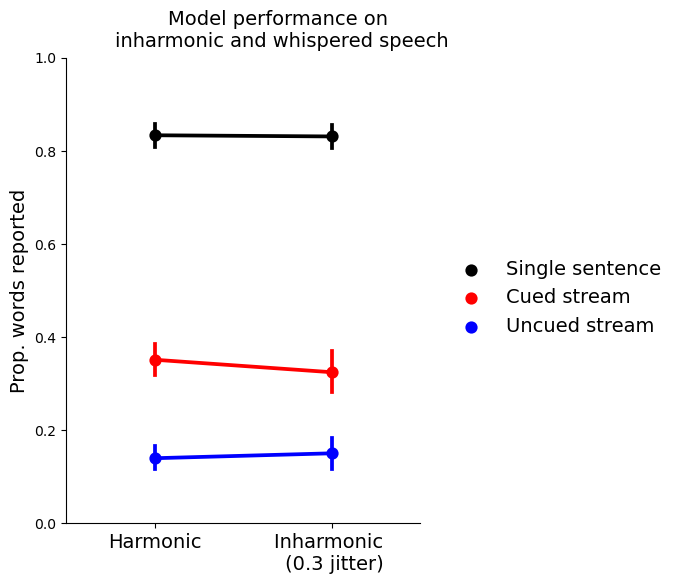

In [127]:
order = ['Harmonic', 'Inharmonic \n (0.3 jitter)']


hues = ['k', 'r', 'b']
hue_order = ['Single sentence', 'Cued stream', 'Uncued stream']
fontsize=14


g = sns.catplot(kind='point',
    data=spch_rslts,
    x='distractor_condition', y='hits',
    hue = 'attended_stream', hue_order=hue_order,
    palette=hues,
    order = order,
#     hue='distractor_condition', hue_order=hue_order, palette=distractor_palette,
#     col='subject',
    seed=1, 
    height=6, aspect=0.75
)


g.set_axis_labels("", "Prop. words reported", size=fontsize)
g.set_xticklabels(rotation=0, size=fontsize)
# g.set_xticklabels(rotation=0, size=fontsize)

# g.set_yticklabels(size=fontsize)

# g.set_titles("{col_name} performance", size=fontsize)
g.legend.set_title("")
# plt.yscale('log')
sns.move_legend(g, title='', 
                loc="center right", bbox_to_anchor=(1.15, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)

plt.ylim(0,1)
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle('Model performance on \ninharmonic and whispered speech', size=fontsize)
# g.fig.tight_layout()

Text(0.5, 0.98, 'Model performance on \ninharmonic and whispered speech')

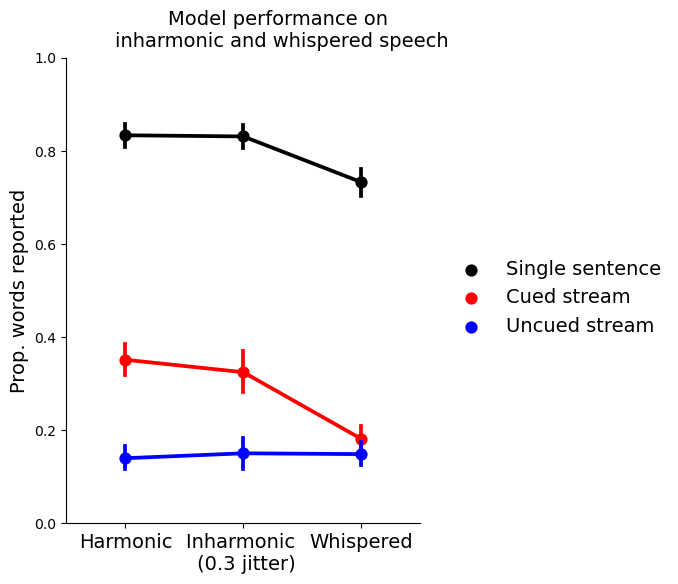

In [128]:
order = ['Harmonic', 'Inharmonic \n (0.3 jitter)', 'Whispered']


hues = ['k', 'r', 'b']
hue_order = ['Single sentence', 'Cued stream', 'Uncued stream']
fontsize=14


g = sns.catplot(kind='point',
    data=spch_rslts,
    x='distractor_condition', y='hits',
    hue = 'attended_stream', hue_order=hue_order,
    palette=hues,
    order = order,
#     hue='distractor_condition', hue_order=hue_order, palette=distractor_palette,
#     col='subject',
    seed=1, 
    height=6, aspect=0.75
)


g.set_axis_labels("", "Prop. words reported", size=fontsize)
g.set_xticklabels(rotation=0, size=fontsize)
# g.set_xticklabels(rotation=0, size=fontsize)

# g.set_yticklabels(size=fontsize)

# g.set_titles("{col_name} performance", size=fontsize)
g.legend.set_title("")
# plt.yscale('log')
sns.move_legend(g, title='', 
                loc="center right", bbox_to_anchor=(1.15, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)

plt.ylim(0,1)
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle('Model performance on \ninharmonic and whispered speech', size=fontsize)
# g.fig.tight_layout()

In [101]:
# order = ['Harmonic', 'Inharmonic \n (0.3 jitter)', 'Whispered']


# hues = ['k', 'r', 'b']
# hue_order = ['Single sentence', 'Cued stream', 'Uncued stream']
# fontsize=14


# g = sns.catplot(kind='point',
#     data=spch_rslts,
#     x='distractor_condition', y='hits',
#     hue = 'attended_stream', hue_order=hue_order,
#     palette=hues,
#     order = order,
# #     hue='distractor_condition', hue_order=hue_order, palette=distractor_palette,
# #     col='subject',
#     seed=1, 
#     height=6, aspect=0.75
# )


# g.set_axis_labels("", "Prop. words reported", size=fontsize)
# g.set_xticklabels(rotation=0, size=fontsize)
# # g.set_xticklabels(rotation=0, size=fontsize)

# # g.set_yticklabels(size=fontsize)

# # g.set_titles("{col_name} performance", size=fontsize)
# g.legend.set_title("")
# # plt.yscale('log')
# sns.move_legend(g, title='', 
#                 loc="center right", bbox_to_anchor=(1.15, .5),
#                 frameon=False, title_size=fontsize, fontsize=fontsize)
# # plt.tick_params(axis='both', which='major', labelsize=16)

# plt.ylim(0,1)
# g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
# g.fig.suptitle('Model performance on \ninharmonic and whispered speech \n inharmonic speech made using shift f0', size=fontsize)
# # g.fig.tight_layout()

Text(0.5, 0.98, 'Model performance on \ninharmonic and whispered speech')

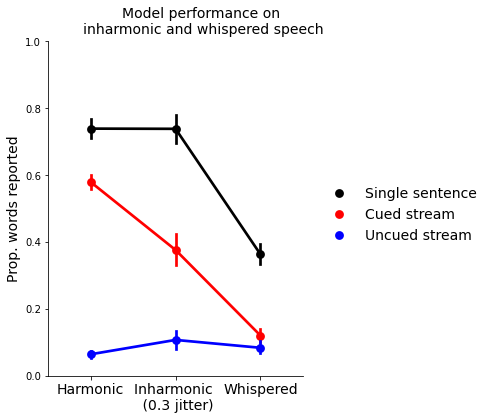

In [130]:
# order = ['Harmonic', 'Inharmonic \n (0.3 jitter)', 'Whispered']


# hues = ['k', 'r', 'b']
# hue_order = ['Single sentence', 'Cued stream', 'Uncued stream']
# fontsize=14


# g = sns.catplot(kind='point',
#     data=spch_rslts,
#     x='distractor_condition', y='hits',
#     hue = 'attended_stream', hue_order=hue_order,
#     palette=hues,
#     order = order,
# #     hue='distractor_condition', hue_order=hue_order, palette=distractor_palette,
# #     col='subject',
#     seed=1, 
#     height=6, aspect=0.75
# )


# g.set_axis_labels("", "Prop. words reported", size=fontsize)
# g.set_xticklabels(rotation=0, size=fontsize)
# # g.set_xticklabels(rotation=0, size=fontsize)

# # g.set_yticklabels(size=fontsize)

# # g.set_titles("{col_name} performance", size=fontsize)
# g.legend.set_title("")
# # plt.yscale('log')
# sns.move_legend(g, title='', 
#                 loc="center right", bbox_to_anchor=(1.15, .5),
#                 frameon=False, title_size=fontsize, fontsize=fontsize)
# # plt.tick_params(axis='both', which='major', labelsize=16)

# plt.ylim(0,1)
# g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
# g.fig.suptitle('Model performance on \ninharmonic and whispered speech', size=fontsize)
# # g.fig.tight_layout()